# Real-data tutorial 2: lung Ccn1–macrophage enrichment

**Dataset:** annotated lung SPAC cohort, section M002.

**Best-supported dataset-level conclusion:** five Ccn1 territories
show increased macrophage fraction within 0–40 µm. The direction is
preserved after structural matching and under core versus hybrid
clone definitions. This is a one-section, one-guide candidate and
therefore remains a validation target rather than a formal
propagation radius.

## 1. Load frozen candidate-level source data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import perturbradius as pr

DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("tutorials/data")
if not DATA_DIR.exists():
    raise FileNotFoundError("Run from the repository root or tutorials directory")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {
    "orange": "#D55E00",
    "blue": "#0072B2",
    "green": "#009E73",
    "purple": "#CC79A7",
    "gray": "#777777",
}
print("PerturbRadius", pr.__version__)

PerturbRadius 0.1.0


In [2]:
coordinates = pd.read_csv(DATA_DIR / "lung_ccn1_source_coordinates.tsv", sep="\t")
radial = pd.read_csv(DATA_DIR / "lung_ccn1_macrophage_radial_matrix.tsv", sep="\t")
boundary = pd.read_csv(DATA_DIR / "lung_ccn1_boundary_sensitivity.tsv", sep="\t")
evidence = pd.read_csv(DATA_DIR / "lung_ccn1_evidence.tsv", sep="\t")
radial = radial.rename(columns={radial.columns[0]: "clone_id"})

summary = pd.DataFrame({
    "quantity": ["source bins", "spatial territories", "sections",
                 "guides", "response"],
    "value": [len(coordinates), radial["clone_id"].nunique(), 1, 1,
              "macrophage fraction"],
})
display(summary)
display(evidence[[
    "gene", "section", "clones", "raw_near_far_effect",
    "raw_permutation_fdr", "matched_near_far_effect",
    "matched_permutation_fdr", "same_direction_fraction",
    "consensus_class",
]].round(4))

,quantity,value
0,source bins,434
1,spatial territories,5
2,sections,1
3,guides,1
4,response,macrophage fraction


,gene,section,clones,raw_near_far_effect,raw_permutation_fdr,matched_near_far_effect,matched_permutation_fdr,same_direction_fraction,consensus_class
0,Ccn1,M002,5.0,0.0934,0.0749,0.068,0.0875,1.0,Within-section triangulated candidate


## 2. Spatial geometry of the five Ccn1 territories

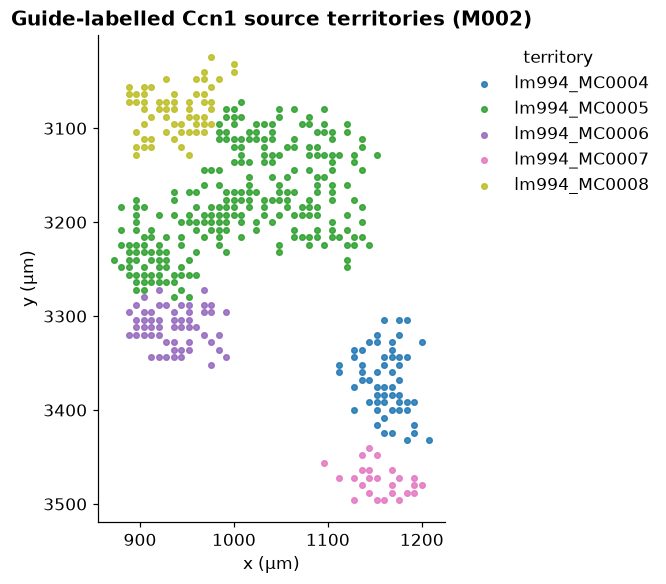

In [3]:
clone_ids = coordinates["clone_id"].drop_duplicates().tolist()
palette = dict(zip(clone_ids, plt.cm.tab10(np.linspace(0, 0.8, len(clone_ids)))))
fig, ax = plt.subplots(figsize=(6.5, 5.2), constrained_layout=True)
for clone_id, rows in coordinates.groupby("clone_id", observed=True):
    ax.scatter(rows["x_um"], rows["y_um"], s=13, color=palette[clone_id],
               label=clone_id, alpha=0.85, rasterized=True)
ax.set(xlabel="x (µm)", ylabel="y (µm)", aspect="equal")
ax.invert_yaxis()
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left",
          title="territory")
ax.set_title("Guide-labelled Ccn1 source territories (M002)", fontweight="bold")
plt.show()

The territories are constructed from guide-labelled source bins.
Spatial proximity among territories makes boundary and overlap
sensitivity essential; the figure should not be read as five
independent animals.

## 3. Clone-specific macrophage response versus boundary distance

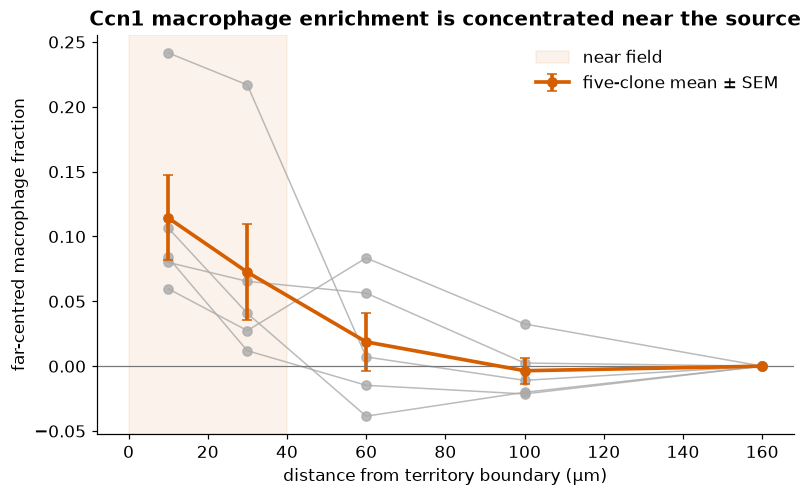

,clone_id,0-20,20-40,40-80,80-120,120-200
0,lm994_MC0004,0.1066,0.0407,-0.0386,-0.0202,0.0
1,lm994_MC0005,0.0597,0.0274,0.0834,0.0325,0.0
2,lm994_MC0006,0.0800,0.0654,0.0563,0.0024,0.0
3,lm994_MC0007,0.0838,0.0119,-0.0148,-0.0214,0.0
4,lm994_MC0008,0.2416,0.2169,0.0071,-0.0109,0.0


In [4]:
ring_labels = [column for column in radial.columns if column != "clone_id"]
ring_midpoints = np.array([10, 30, 60, 100, 160], dtype=float)
values = radial[ring_labels].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
for row, clone_id in zip(values, radial["clone_id"]):
    ax.plot(ring_midpoints, row, marker="o", linewidth=1,
            color="#AAAAAA", alpha=0.8)
mean = values.mean(axis=0)
sem = values.std(axis=0, ddof=1) / np.sqrt(len(values))
ax.errorbar(ring_midpoints, mean, yerr=sem, marker="o", linewidth=2.4,
            capsize=3, color=COLORS["orange"], label="five-clone mean ± SEM")
ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
ax.axvspan(0, 40, color=COLORS["orange"], alpha=0.08, label="near field")
ax.set(xlabel="distance from territory boundary (µm)",
       ylabel="far-centred macrophage fraction")
ax.set_title("Ccn1 macrophage enrichment is concentrated near the source",
             fontweight="bold")
ax.legend(frameon=False)
plt.show()
display(radial.round(4))

## 4. Core-versus-hybrid boundary sensitivity

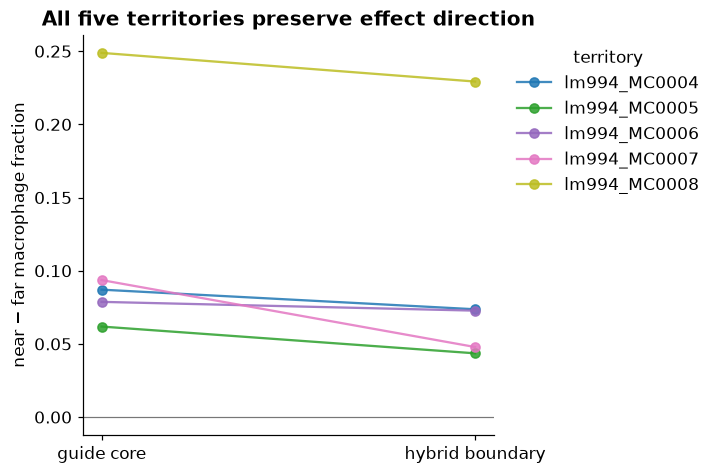

,clone_id,core_effect,hybrid_effect,same_direction,absolute_change
0,lm994_MC0004,0.0870,0.0736,1.0,0.0134
1,lm994_MC0005,0.0618,0.0435,1.0,0.0183
2,lm994_MC0006,0.0787,0.0727,1.0,0.0060
3,lm994_MC0007,0.0936,0.0479,1.0,0.0458
4,lm994_MC0008,0.2488,0.2292,1.0,0.0196


In [5]:
fig, ax = plt.subplots(figsize=(6.4, 4.2), constrained_layout=True)
for row in boundary.itertuples():
    ax.plot([0, 1], [row.core_effect, row.hybrid_effect],
            marker="o", color=palette[row.clone_id], alpha=0.85,
            label=row.clone_id)
ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
ax.set_xticks([0, 1], ["guide core", "hybrid boundary"])
ax.set_ylabel("near − far macrophage fraction")
ax.set_title("All five territories preserve effect direction", fontweight="bold")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left",
          title="territory")
plt.show()
display(boundary[[
    "clone_id", "core_effect", "hybrid_effect", "same_direction",
    "absolute_change",
]].round(4))

## 5. Evidence triangulation and reporting gate

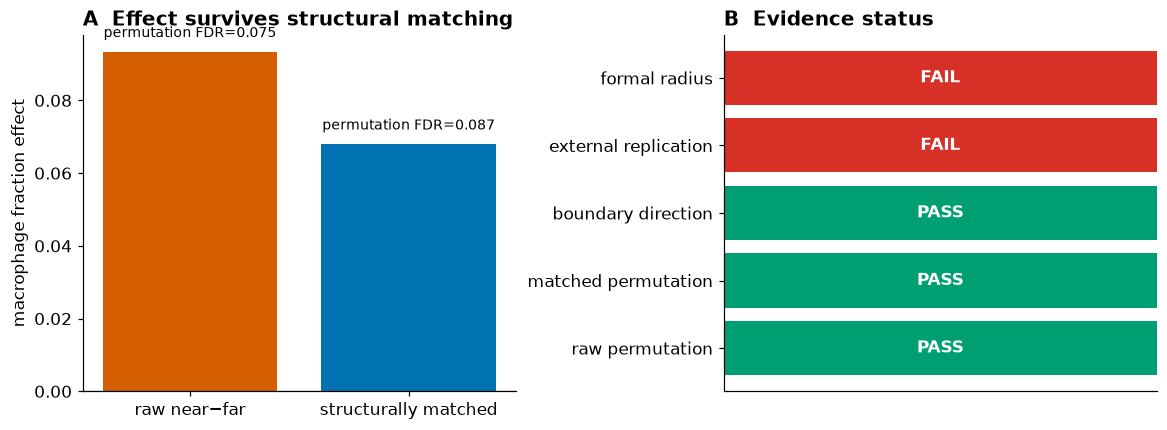

In [6]:
row = evidence.iloc[0]
labels = ["raw near−far", "structurally matched"]
effects = [row["raw_near_far_effect"], row["matched_near_far_effect"]]
fdrs = [row["raw_permutation_fdr"], row["matched_permutation_fdr"]]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
bars = axes[0].bar(labels, effects, color=[COLORS["orange"], COLORS["blue"]])
axes[0].axhline(0, color=COLORS["gray"], linewidth=0.8)
axes[0].set_ylabel("macrophage fraction effect")
axes[0].set_title("A  Effect survives structural matching", loc="left",
                  fontweight="bold")
for bar, fdr in zip(bars, fdrs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f"permutation FDR={fdr:.3f}", ha="center", fontsize=9)

gate_labels = ["raw permutation", "matched permutation",
               "boundary direction", "external replication",
               "formal radius"]
gate_values = [
    bool(row["raw_supported"]), bool(row["matched_supported"]),
    bool(row["boundary_robust"]), bool(row["external_supported"]), False,
]
colors = [COLORS["green"] if value else "#D73027" for value in gate_values]
axes[1].barh(gate_labels, np.ones(len(gate_values)), color=colors)
for y, value in enumerate(gate_values):
    axes[1].text(0.5, y, "PASS" if value else "FAIL", ha="center",
                 va="center", color="white", fontweight="bold")
axes[1].set_xlim(0, 1)
axes[1].set_xticks([])
axes[1].set_title("B  Evidence status", loc="left", fontweight="bold")
plt.show()

## Conclusion

Ccn1 is the clearest annotated-lung candidate for local macrophage
enrichment: raw effect +0.093, structurally matched effect +0.068,
permutation FDR values approximately 0.075 and 0.087, and 5/5
core/hybrid direction agreement. The result is still confined to
M002 and one sgRNA. It supports a **within-section spatial
association requiring external validation**, not a causal λ, R50
or R5% estimate.